# Supervised Classification: High-Value-Customer erkennen

In diesem Notebook wird ein Klassifikationsmodell für den Online-Retail-Datensatz erstellt.

Ziel ist es, vorherzusagen, ob ein Kunde zu den umsatzstärksten Kunden gehört. Dafür wird aus dem bereinigten Datensatz eine Zielvariable **HighValueCustomer** gebildet.

Die Analyse baut auf dem vorherigen Notebook zur Datenbereinigung auf und verwendet daher den bereits bereinigten Datensatz.

## 1. Bibliotheken importieren

Zuerst werden die benötigten Bibliotheken geladen. Pandas wird für die Datenaufbereitung verwendet. Scikit-Learn wird für Train-Test-Split, Skalierung, Modelltraining und Bewertung verwendet.

In [1]:
# Datenanalyse
import pandas as pd
import numpy as np

# Visualisierung
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

## 2. Bereinigten Datensatz laden

Der Datensatz wurde bereits im ersten Notebook bereinigt. Deshalb werden hier keine erneuten Bereinigungsschritte durchgeführt.

Der Dateipfad bleibt unverändert und verweist auf die bereinigte CSV-Datei im Ordner `data`.

In [2]:
# Bereinigten Online-Retail-Datensatz laden
# parse_dates sorgt dafür, dass InvoiceDate direkt als Datum erkannt wird.
df = pd.read_csv(
    "../data/online_retail_data_cleaned.csv",
    parse_dates=["InvoiceDate"]
)

# Erste fünf Zeilen anzeigen
df.head()

/tmp/ipykernel_51547/1620373253.py:3: DtypeWarning: Columns (0: InvoiceNo) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,InvoiceMonth,IsCancellation
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12-01,False
1,536365,71053,WHITE METAL LANTERN,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12-01,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12-01,False


## 3. Kundendaten erstellen

Der ursprüngliche Datensatz enthält einzelne Rechnungspositionen. Für die Klassifikation wird jedoch eine Kundensicht benötigt.

Daher wird pro `CustomerID` eine Zeile erstellt. Aus den Transaktionen werden Kennzahlen wie Umsatz, Anzahl der Bestellungen, gekaufte Menge und Anzahl unterschiedlicher Produkte gebildet.

In [3]:
# Kundendaten aus den Transaktionsdaten erzeugen
customer_data = df.groupby("CustomerID").agg({
    "TotalPrice": "sum",
    "InvoiceNo": "nunique",
    "Quantity": "sum",
    "StockCode": "nunique"
}).reset_index()

# Spalten verständlich umbenennen
customer_data.columns = [
    "CustomerID",
    "total_revenue",
    "number_of_orders",
    "total_quantity",
    "unique_products"
]

# Durchschnittlicher Bestellwert pro Kunde
customer_data["avg_order_value"] = (
    customer_data["total_revenue"] / customer_data["number_of_orders"]
)

customer_data.head()

,CustomerID,total_revenue,number_of_orders,total_quantity,unique_products,avg_order_value
0,12346.0,77183.60,1,74215.0,1,77183.600000
1,12347.0,4310.00,7,2458.0,103,615.714286
2,12348.0,1797.24,4,2341.0,22,449.310000
3,12349.0,1757.55,1,631.0,73,1757.550000
4,12350.0,334.40,1,197.0,17,334.400000


## 4. Zielvariable erstellen: HighValueCustomer

Da der Retail-Datensatz keine fertige Zielvariable enthält, wird eine eigene Zielvariable erstellt.

Ein Kunde wird als **HighValueCustomer** markiert, wenn sein Gesamtumsatz zu den oberen 25 % aller Kunden gehört.

- `1` = High-Value-Customer
- `0` = normaler Kunde

In [4]:
# Grenze für die umsatzstärksten 25 % berechnen
threshold = customer_data["total_revenue"].quantile(0.75)

# Zielvariable erzeugen
customer_data["HighValueCustomer"] = (
    customer_data["total_revenue"] >= threshold
).astype(int)

# Verteilung der Zielvariable anzeigen
customer_data["HighValueCustomer"].value_counts()

HighValueCustomer
0    3253
1    1085
Name: count, dtype: int64

## 5. Features und Zielvariable definieren

Für die Vorhersage werden nur Merkmale verwendet, die nicht direkt die Zielvariable erzeugen.

`total_revenue` wird bewusst **nicht** als Feature verwendet, weil daraus die Zielvariable gebildet wurde. Würde man `total_revenue` trotzdem verwenden, hätte das Modell die Lösung praktisch schon direkt im Input. Das nennt man Data Leakage.

In [5]:
# Eingabevariablen für das Modell
features = [
    "number_of_orders",
    "total_quantity",
    "unique_products",
    "avg_order_value"
]

X = customer_data[features]
y = customer_data["HighValueCustomer"]

X.head()

,number_of_orders,total_quantity,unique_products,avg_order_value
0,1,74215.0,1,77183.600000
1,7,2458.0,103,615.714286
2,4,2341.0,22,449.310000
3,1,631.0,73,1757.550000
4,1,197.0,17,334.400000


## 6. Train-Test-Split

Die Daten werden in Trainings- und Testdaten aufgeteilt.

Das Modell lernt auf den Trainingsdaten und wird danach auf den Testdaten geprüft. Durch `stratify=y` bleibt das Verhältnis zwischen normalen Kunden und High-Value-Customern in beiden Datensätzen ähnlich.

In [6]:
# Daten in Trainings- und Testdaten aufteilen
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Trainingsdaten:", X_train.shape)
print("Testdaten:", X_test.shape)

Trainingsdaten: (3470, 4)
Testdaten: (868, 4)


## 7. Skalierung der Features

Für KNN ist Skalierung wichtig, weil das Modell mit Abständen arbeitet. Damit alle Modelle fair vergleichbar bleiben, werden dieselben skalierten Daten auch für Decision Tree und Naive Bayes verwendet.

In [7]:
# Features skalieren
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 8. Modelle trainieren

Es werden drei Klassifikationsmodelle trainiert:

1. Decision Tree
2. K-Nearest Neighbors
3. Naive Bayes

Diese Modelle passen gut zu einem Einstieg in Supervised Learning und lassen sich einfach miteinander vergleichen.

In [8]:
# Decision Tree Modell
decision_tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

decision_tree.fit(X_train_scaled, y_train)

# KNN Modell
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Naive Bayes Modell
naive_bayes = GaussianNB()
naive_bayes.fit(X_train_scaled, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


## 9. Modelle vergleichen

Die Modelle werden mit Accuracy verglichen. Accuracy zeigt, wie viele Vorhersagen insgesamt richtig waren.

Zusätzlich wird später ein Classification Report verwendet, weil dort Precision, Recall und F1-Score sichtbar werden.

In [9]:
# Modelle in einem Dictionary sammeln
models = {
    "Decision Tree": decision_tree,
    "KNN": knn,
    "Naive Bayes": naive_bayes
}

# Accuracy für jedes Modell berechnen
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    print(name)
    print("Accuracy:", round(accuracy, 3))
    print()

Decision Tree
Accuracy: 0.965

KNN
Accuracy: 0.965

Naive Bayes
Accuracy: 0.906



## 10. Classification Report für das beste Modell

Der Decision Tree wird genauer betrachtet, weil er leicht interpretierbar ist und sich gut erklären lässt.

Der Classification Report zeigt:

- **Precision**: Wie viele als High-Value-Customer vorhergesagte Kunden waren wirklich High-Value-Customer?
- **Recall**: Wie viele echte High-Value-Customer wurden erkannt?
- **F1-Score**: Kombination aus Precision und Recall.

In [10]:
# Vorhersagen mit dem Decision Tree
best_model = decision_tree
y_pred = best_model.predict(X_test_scaled)

# Ausführliche Bewertung anzeigen
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       651
           1       0.96      0.90      0.93       217

    accuracy                           0.97       868
   macro avg       0.96      0.94      0.95       868
weighted avg       0.97      0.97      0.97       868



## 11. Confusion Matrix

Die Confusion Matrix zeigt, wie viele Kunden richtig oder falsch klassifiziert wurden.

Dadurch erkennt man, ob das Modell eher normale Kunden oder High-Value-Customer verwechselt.

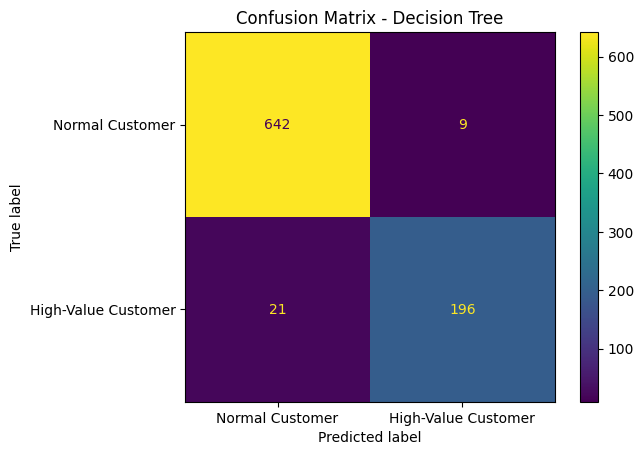

In [11]:
# Confusion Matrix berechnen und anzeigen
cm = confusion_matrix(y_test, y_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal Customer", "High-Value Customer"]
)

display.plot()
plt.title("Confusion Matrix - Decision Tree")
plt.show()

## 12. Decision Tree visualisieren

Ein Vorteil des Decision Trees ist, dass man seine Entscheidungslogik grafisch darstellen kann.

So lässt sich nachvollziehen, nach welchen Merkmalen das Modell Kunden klassifiziert.

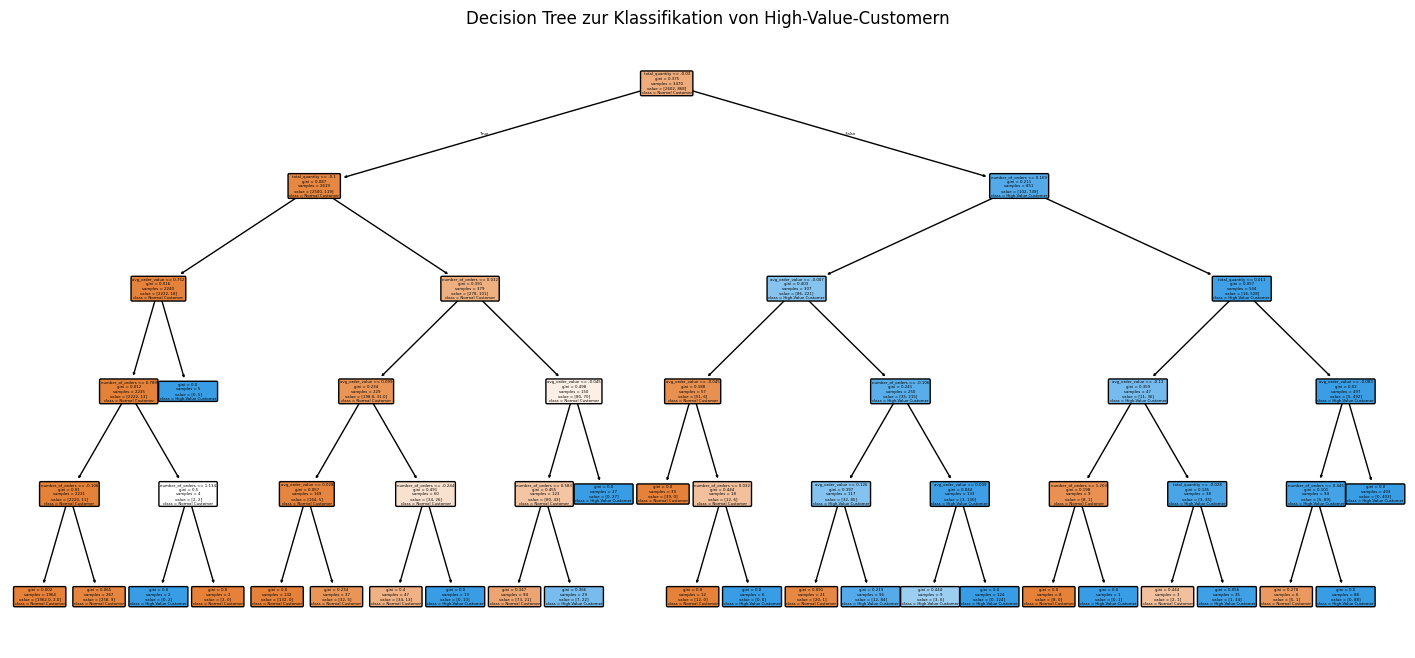

In [12]:
# Decision Tree grafisch darstellen
plt.figure(figsize=(18, 8))

plot_tree(
    decision_tree,
    feature_names=features,
    class_names=["Normal Customer", "High-Value Customer"],
    filled=True,
    rounded=True
)

plt.title("Decision Tree zur Klassifikation von High-Value-Customern")
plt.show()

## 13. Feature Importance

Die Feature Importance zeigt, welche Merkmale für den Decision Tree am wichtigsten waren.

In [13]:
# Wichtigkeit der Features berechnen
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": decision_tree.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
1,total_quantity,0.802229
3,avg_order_value,0.114735
0,number_of_orders,0.083036
2,unique_products,0.000000


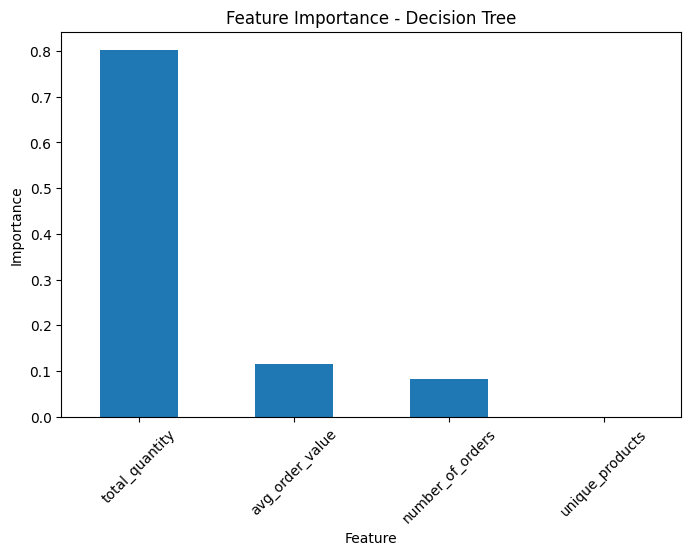

In [14]:
# Feature Importance visualisieren
feature_importance.plot(
    kind="bar",
    x="Feature",
    y="Importance",
    legend=False,
    figsize=(8, 5)
)

plt.title("Feature Importance - Decision Tree")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

## 14. Ergebnisse exportieren

Zum Schluss werden die Kundendaten inklusive Zielvariable und Vorhersage exportiert. Dadurch können die Ergebnisse später weiterverwendet oder in der Projektarbeit dokumentiert werden.

In [15]:
# Vorhersagen für alle Kunden erstellen
customer_data["PredictedHighValueCustomer"] = best_model.predict(
    scaler.transform(customer_data[features])
)

# Ergebnisdatei speichern
customer_data.to_csv(
    "../data/online_retail_high_value_customer_predictions.csv",
    index=False
)

customer_data.head()

,CustomerID,total_revenue,number_of_orders,total_quantity,unique_products,avg_order_value,HighValueCustomer,PredictedHighValueCustomer
0,12346.0,77183.60,1,74215.0,1,77183.600000,1,1
1,12347.0,4310.00,7,2458.0,103,615.714286,1,1
2,12348.0,1797.24,4,2341.0,22,449.310000,1,1
3,12349.0,1757.55,1,631.0,73,1757.550000,1,1
4,12350.0,334.40,1,197.0,17,334.400000,0,0


## 15. Kurze Interpretation

In diesem Notebook wurde ein Supervised-Learning-Modell erstellt, das Kunden in normale Kunden und High-Value-Customer einteilt.

Die Zielvariable wurde auf Basis des Gesamtumsatzes erstellt. Für das Modell wurden jedoch andere Kundenmerkmale verwendet, um Data Leakage zu vermeiden.

Damit ergänzt dieses Notebook die vorherige Clusteranalyse: Während das Unsupervised Learning Kundengruppen ohne vorgegebene Zielvariable findet, sagt das Supervised Learning gezielt voraus, ob ein Kunde zur Gruppe der besonders wertvollen Kunden gehört.